LIBRARIES

In [32]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [33]:
IMG_HEIGHT=224
IMG_WIDTH=224
IMG_CHANNELS=3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [34]:
train_dataset= tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode= 'int',
    batch_size = 16,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels ='inferred',
    label_mode='int',
    batch_size=16,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)

normalize=tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [35]:
resnet = tf.keras.applications.ResNet50(
    include_top=False,
    weights ='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
)

model= keras.Sequential([
    resnet,
    keras.layers.AvgPool2D(pool_size=7),

    keras.layers.Flatten(),

    keras.layers.Dense(500),
    keras.layers.ReLU(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

resnet.trainable =False
model.trainable = True

model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 1, 2048)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         2,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,614,717 (93.90 MB)

 Trainable params: 1,027,005 (3.92 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

TRAINING

In [36]:
EPOCHS= 10
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 155s 794ms/step - accuracy: 0.2237 - loss: 1.6913 - val_accuracy: 0.3450 - val_loss: 1.5435
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 177s 943ms/step - accuracy: 0.2643 - loss: 1.5672 - val_accuracy: 0.3140 - val_loss: 1.5314
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 156s 830ms/step - accuracy: 0.2910 - loss: 1.5512 - val_accuracy: 0.2720 - val_loss: 1.5327
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.3000 - loss: 1.5357 - val_accuracy: 0.3230 - val_loss: 1.5100
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.3070 - loss: 1.5225 - val_accuracy: 0.3410 - val_loss: 1.5095
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.3037 - loss: 1.5250 - val_accuracy: 0.3890 - val_loss: 1.4994
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.3070 - loss: 1.5190 - val_accuracy: 0.3170 - val_loss: 1.5051
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.3280 - loss: 1.5120 -

PLOTTING

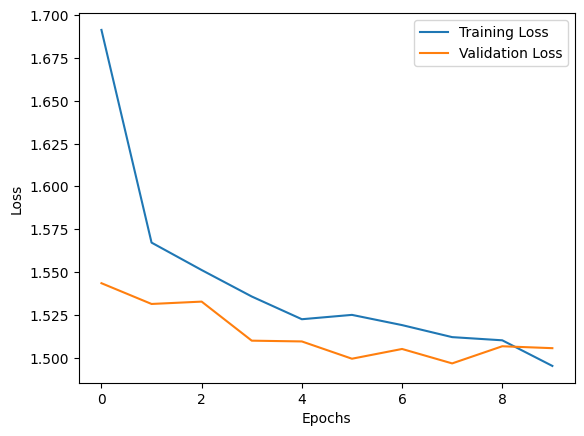

In [37]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

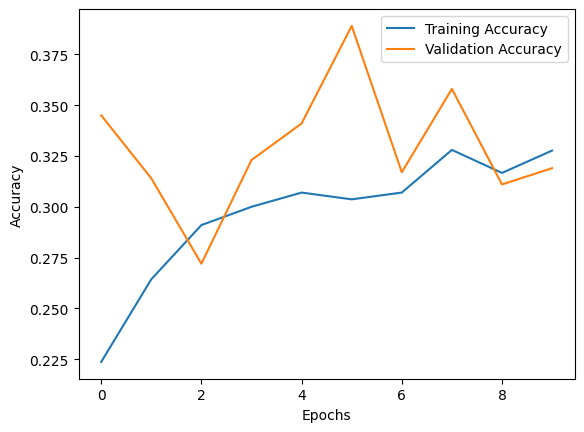

In [38]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()